In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#df=pd.read_csv(r'MSBOS_DATA.csv', encoding='latin1', sep=';', header=None, on_bad_lines='skip')

In [ ]:
df=pd.read_csv(r'MSBOS DATA mod.csv', encoding='latin1', on_bad_lines='skip')

In [ ]:
df.head()

,SL. NO,DATE,BBR NO,HOSP NO,AGE,GENDER,DEPARTMENT,UNIT,DIAGNOSIS,PROCEDURE SEGREGATED,PROCEDURE,BLOOD UNITS REQUESTED,BLOOD UNITS CROSSMATCHED,BLOOD UNITS ISSUES,PRE HB
0,1,23/1/24,1041.0,1438616.0,15,F,PEDS SURG,NaN,PSEUDOCYST PANCREAS,LAPAROTOMY,INTERNAL DRAINAGE AND RESECTION,1,1.0,0,8.2
1,2,22/1/24,990.0,687102.0,11,F,PEDS SURG,NaN,PERSISTENT CLOACA,LAPAROTOMY,RECONSTRUCTIVE SURGERY,2,1.0,1,12.9
2,3,23/1/24,1059.0,854359.0,63,F,SURG ONCO,NaN,CA RIGHT BREAST,MASTECTOMY,MASTECTOMY,2,0.0,0,12.5
3,4,23.1.24,1058.0,1431486.0,74,F,SURG ONCO,NaN,CA RIGHT BREAST,MASTECTOMY,MASTECTOMY,2,0.0,0,10.7
4,5,24/1/24,1047.0,29681.0,42,M,NEURO SURG,NaN,L4 L5 DISC PROLAPSE,SPINE SURGERY,DISCECTOMY,1,0.0,0,14.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1778 entries, 0 to 1777
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SL. NO                    1778 non-null   int64  
 1   DATE                      1774 non-null   object 
 2   BBR NO                    1766 non-null   float64
 3   HOSP NO                   1774 non-null   float64
 4   AGE                       1773 non-null   object 
 5   GENDER                    1773 non-null   object 
 6   DEPARTMENT                1774 non-null   object 
 7   UNIT                      463 non-null    float64
 8   DIAGNOSIS                 1773 non-null   object 
 9   PROCEDURE SEGREGATED      1774 non-null   object 
 10  PROCEDURE                 1583 non-null   object 
 11  BLOOD UNITS REQUESTED     1772 non-null   object 
 12  BLOOD UNITS CROSSMATCHED  1772 non-null   float64
 13  BLOOD UNITS ISSUES        1772 non-null   object 
 14  PRE HB  

In [ ]:
df.describe()

,SL. NO,BBR NO,HOSP NO,UNIT,BLOOD UNITS CROSSMATCHED
count,1778.000000,1766.000000,1.774000e+03,463.000000,1772.000000
mean,889.500000,6840.519819,7.178973e+06,1.609071,0.500564
std,513.408707,6680.555223,1.130129e+08,0.592598,0.864312
min,1.000000,2.000000,1.370000e+02,1.000000,0.000000
25%,445.250000,2106.250000,1.767145e+05,1.000000,0.000000
50%,889.500000,4242.500000,4.110715e+05,2.000000,0.000000
75%,1333.750000,12291.750000,1.130594e+06,2.000000,1.000000
max,1778.000000,165481.000000,2.400868e+09,3.000000,8.000000


In [ ]:
df.isnull().sum()

,0
SL. NO,0
DATE,4
BBR NO,12
HOSP NO,4
AGE,5
GENDER,5
DEPARTMENT,4
UNIT,1315
DIAGNOSIS,5
PROCEDURE SEGREGATED,4


In [ ]:
df=df.drop(columns=['PROCEDURE'])

In [ ]:
df1=df.copy()

In [ ]:
df1['UNIT'] = df1['UNIT'].fillna(0)
df1.isnull().sum()

,0
SL. NO,0
DATE,4
BBR NO,12
HOSP NO,4
AGE,5
GENDER,5
DEPARTMENT,4
UNIT,0
DIAGNOSIS,5
PROCEDURE SEGREGATED,4


In [ ]:
mode_hosp_no = df1['HOSP NO'].mode()[0]
df1['HOSP NO'] = df1['HOSP NO'].fillna(mode_hosp_no)
df1.isnull().sum()

,0
SL. NO,0
DATE,4
BBR NO,12
HOSP NO,0
AGE,5
GENDER,5
DEPARTMENT,4
UNIT,0
DIAGNOSIS,5
PROCEDURE SEGREGATED,4


In [ ]:
df1['GENDER'] = df1['GENDER'].fillna('M')
df1.isnull().sum()

,0
SL. NO,0
DATE,4
BBR NO,12
HOSP NO,0
AGE,5
GENDER,0
DEPARTMENT,4
UNIT,0
DIAGNOSIS,5
PROCEDURE SEGREGATED,4


In [ ]:
age_mode = df1['AGE'].mode()[0]
df1['AGE'] = df1['AGE'].fillna(age_mode)


In [ ]:
df1['DEPARTMENT'] = df1['DEPARTMENT'].fillna(df1['DEPARTMENT'].mode()[0])

In [ ]:
df1.isnull().sum()

,0
SL. NO,0
DATE,4
BBR NO,12
HOSP NO,0
AGE,0
GENDER,0
DEPARTMENT,0
UNIT,0
DIAGNOSIS,5
PROCEDURE SEGREGATED,4


In [ ]:
df1.dropna(subset=['BLOOD UNITS REQUESTED'], inplace=True)
df1.isnull().sum()

,0
SL. NO,0
DATE,0
BBR NO,8
HOSP NO,0
AGE,0
GENDER,0
DEPARTMENT,0
UNIT,0
DIAGNOSIS,1
PROCEDURE SEGREGATED,0


In [ ]:
bbr_no_mode = df1['BBR NO'].mode()[0]
df1['BBR NO'] = df1['BBR NO'].fillna(bbr_no_mode)
df1.isnull().sum()

,0
SL. NO,0
DATE,0
BBR NO,0
HOSP NO,0
AGE,0
GENDER,0
DEPARTMENT,0
UNIT,0
DIAGNOSIS,1
PROCEDURE SEGREGATED,0


In [ ]:
df1.dropna(subset=['PRE HB'], inplace=True)
df1.isnull().sum()

,0
SL. NO,0
DATE,0
BBR NO,0
HOSP NO,0
AGE,0
GENDER,0
DEPARTMENT,0
UNIT,0
DIAGNOSIS,1
PROCEDURE SEGREGATED,0


In [ ]:
df1=df1.dropna()

In [ ]:
df.shape

(1778, 14)

In [ ]:
df1.shape

(1766, 14)

In [ ]:
df=df1.copy()

In [ ]:
df.head()

,SL. NO,DATE,BBR NO,HOSP NO,AGE,GENDER,DEPARTMENT,UNIT,DIAGNOSIS,PROCEDURE SEGREGATED,BLOOD UNITS REQUESTED,BLOOD UNITS CROSSMATCHED,BLOOD UNITS ISSUES,PRE HB
0,1,23/1/24,1041.0,1438616.0,15,F,PEDS SURG,0.0,PSEUDOCYST PANCREAS,LAPAROTOMY,1,1.0,0,8.2
1,2,22/1/24,990.0,687102.0,11,F,PEDS SURG,0.0,PERSISTENT CLOACA,LAPAROTOMY,2,1.0,1,12.9
2,3,23/1/24,1059.0,854359.0,63,F,SURG ONCO,0.0,CA RIGHT BREAST,MASTECTOMY,2,0.0,0,12.5
3,4,23.1.24,1058.0,1431486.0,74,F,SURG ONCO,0.0,CA RIGHT BREAST,MASTECTOMY,2,0.0,0,10.7
4,5,24/1/24,1047.0,29681.0,42,M,NEURO SURG,0.0,L4 L5 DISC PROLAPSE,SPINE SURGERY,1,0.0,0,14.3


In [ ]:
df.to_csv('MSBOS_DATA_mod_CLEANED.csv', index=False)

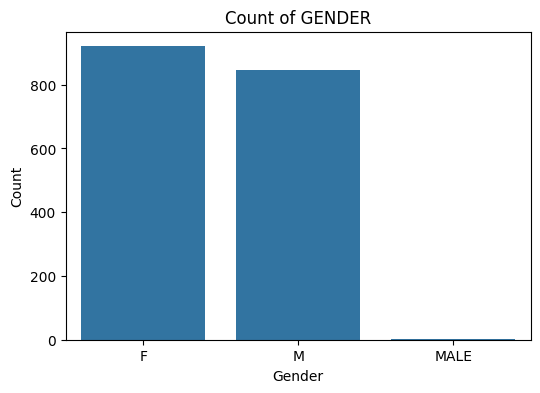

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(data=df1, x='GENDER')
plt.title('Count of GENDER')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [ ]:
df1['BLOOD UNITS REQUESTED'] = pd.to_numeric(df1['BLOOD UNITS REQUESTED'], errors='coerce').fillna(0)
df1['BLOOD UNITS ISSUES'] = pd.to_numeric(df1['BLOOD UNITS ISSUES'], errors='coerce').fillna(0)

print(f"Data type of 'BLOOD UNITS REQUESTED': {df1['BLOOD UNITS REQUESTED'].dtype}")
print(f"Data type of 'BLOOD UNITS ISSUES': {df1['BLOOD UNITS ISSUES'].dtype}")

Data type of 'BLOOD UNITS REQUESTED': float64
Data type of 'BLOOD UNITS ISSUES': float64


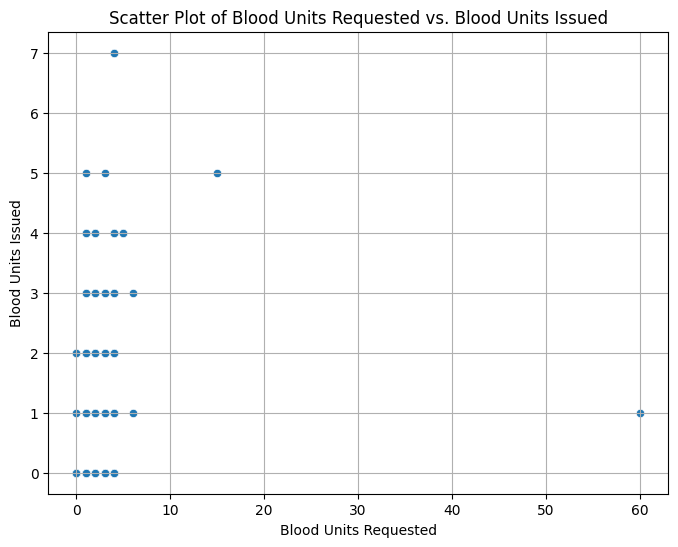

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df1, x='BLOOD UNITS REQUESTED', y='BLOOD UNITS ISSUES')
plt.title('Scatter Plot of Blood Units Requested vs. Blood Units Issued')
plt.xlabel('Blood Units Requested')
plt.ylabel('Blood Units Issued')
plt.grid(True)
plt.show()

In [ ]:
correlation = df1['BLOOD UNITS REQUESTED'].corr(df1['BLOOD UNITS ISSUES'])
print(f"Correlation between 'BLOOD UNITS REQUESTED' and 'BLOOD UNITS ISSUES': {correlation:.2f}")

Correlation between 'BLOOD UNITS REQUESTED' and 'BLOOD UNITS ISSUES': 0.24


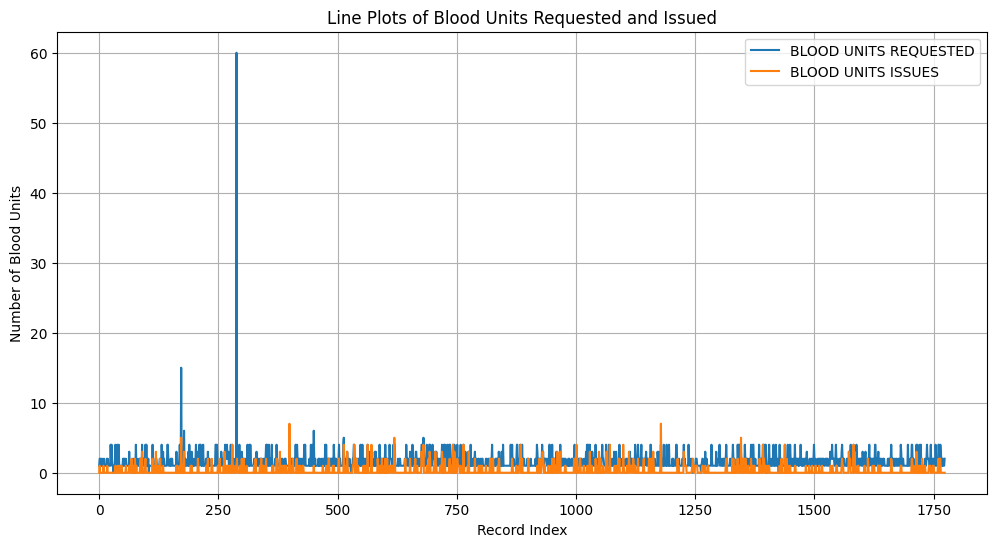

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df1.index, df1['BLOOD UNITS REQUESTED'], label='BLOOD UNITS REQUESTED')
plt.plot(df1.index, df1['BLOOD UNITS ISSUES'], label='BLOOD UNITS ISSUES')
plt.title('Line Plots of Blood Units Requested and Issued')
plt.xlabel('Record Index')
plt.ylabel('Number of Blood Units')
plt.legend()
plt.grid(True)
plt.show()

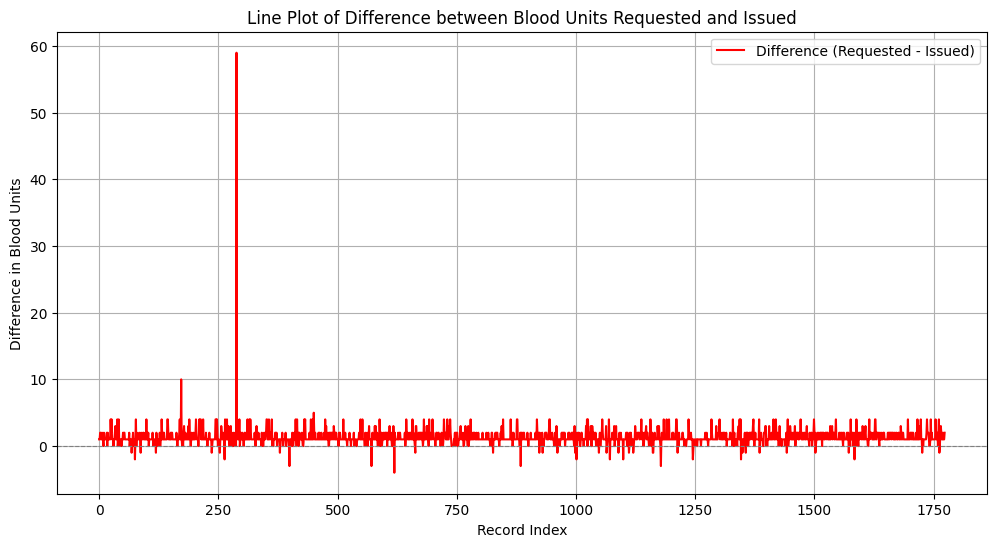

In [ ]:
import matplotlib.pyplot as plt

df1['BLOOD UNITS DIFFERENCE'] = df1['BLOOD UNITS REQUESTED'] - df1['BLOOD UNITS ISSUES']

plt.figure(figsize=(12, 6))
plt.plot(df1.index, df1['BLOOD UNITS DIFFERENCE'], label='Difference (Requested - Issued)', color='red')
plt.title('Line Plot of Difference between Blood Units Requested and Issued')
plt.xlabel('Record Index')
plt.ylabel('Difference in Blood Units')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df.head()

,SL. NO,DATE,BBR NO,HOSP NO,AGE,GENDER,DEPARTMENT,UNIT,DIAGNOSIS,PROCEDURE SEGREGATED,BLOOD UNITS REQUESTED,BLOOD UNITS CROSSMATCHED,BLOOD UNITS ISSUES,PRE HB
0,1,23/1/24,1041.0,1438616.0,15,F,PEDS SURG,0.0,PSEUDOCYST PANCREAS,LAPAROTOMY,1,1.0,0,8.2
1,2,22/1/24,990.0,687102.0,11,F,PEDS SURG,0.0,PERSISTENT CLOACA,LAPAROTOMY,2,1.0,1,12.9
2,3,23/1/24,1059.0,854359.0,63,F,SURG ONCO,0.0,CA RIGHT BREAST,MASTECTOMY,2,0.0,0,12.5
3,4,23.1.24,1058.0,1431486.0,74,F,SURG ONCO,0.0,CA RIGHT BREAST,MASTECTOMY,2,0.0,0,10.7
4,5,24/1/24,1047.0,29681.0,42,M,NEURO SURG,0.0,L4 L5 DISC PROLAPSE,SPINE SURGERY,1,0.0,0,14.3


In [ ]:
df1['AGE'] = pd.to_numeric(df1['AGE'], errors='coerce')
age_mode = df1['AGE'].mode()[0]
df1['AGE'] = df1['AGE'].fillna(age_mode).astype(int)

print(f"Data type of 'AGE': {df1['AGE'].dtype}")

Data type of 'AGE': int64


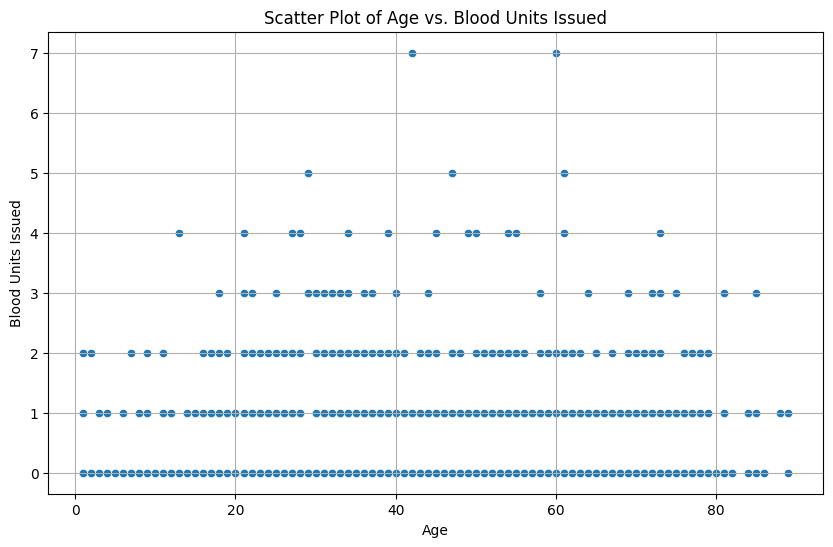

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='AGE', y='BLOOD UNITS ISSUES')
plt.title('Scatter Plot of Age vs. Blood Units Issued')
plt.xlabel('Age')
plt.ylabel('Blood Units Issued')
plt.grid(True)
plt.show()

In [ ]:
correlation_age_issues = df1['AGE'].corr(df1['BLOOD UNITS ISSUES'])
print(f"Correlation between 'AGE' and 'BLOOD UNITS ISSUES': {correlation_age_issues:.2f}")

Correlation between 'AGE' and 'BLOOD UNITS ISSUES': 0.06


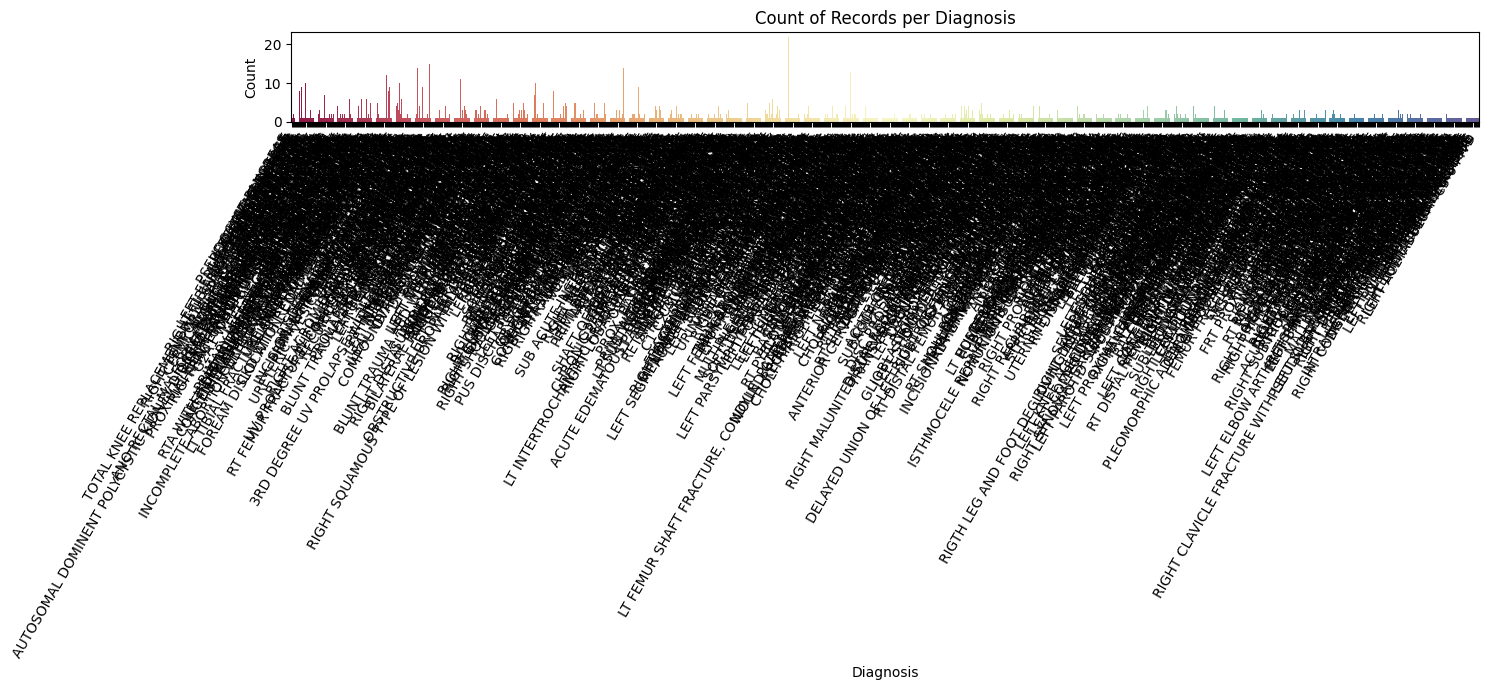

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7)) # Increased figure size for potentially many diagnoses
sns.countplot(data=df1, x='DIAGNOSIS', hue='DIAGNOSIS', palette='Spectral', legend=False)
plt.title('Count of Records per Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right') # Rotate labels for better readability if they are long
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

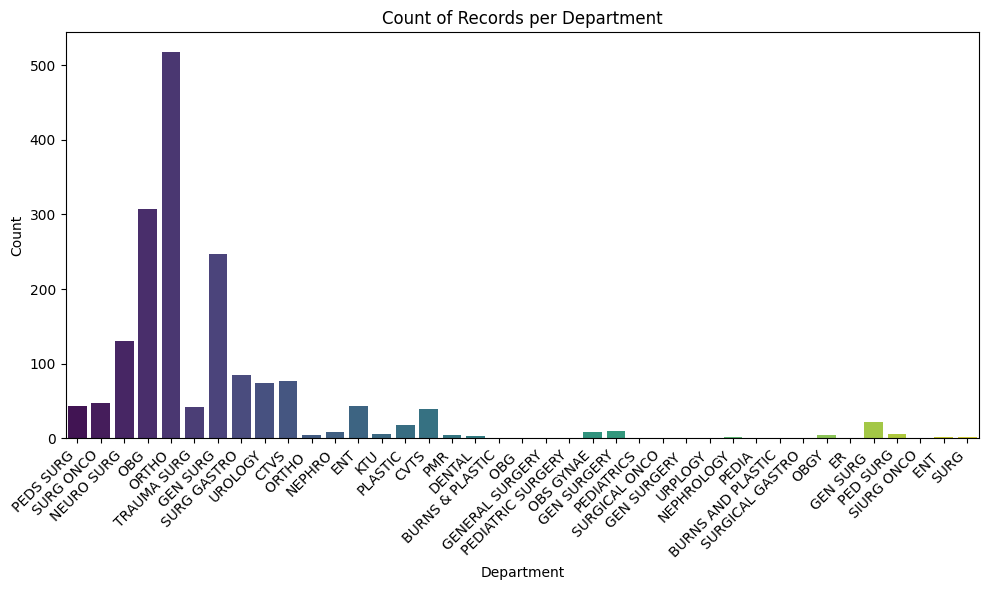

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df1, x='DEPARTMENT', hue='DEPARTMENT', palette='viridis', legend=False)
plt.title('Count of Records per Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
print(f"Number of unique procedures: {df1['PROCEDURE SEGREGATED'].nunique()}")
display(df1['PROCEDURE SEGREGATED'].value_counts().head(10))

Number of unique procedures: 26


,count
PROCEDURE SEGREGATED,
OPEN REDUCTION AND INTERNAL FIXATION/ BONE SURGERY,340
GYNAE CASES,176
LAPAROTOMY,160
OTHERS,131
CABG/CARDIAC,116
INTRAABDOMINAL GI,103
INTRACRANIAL SURGERY,88
LSCS,88
UROLOGY SURGERY,75


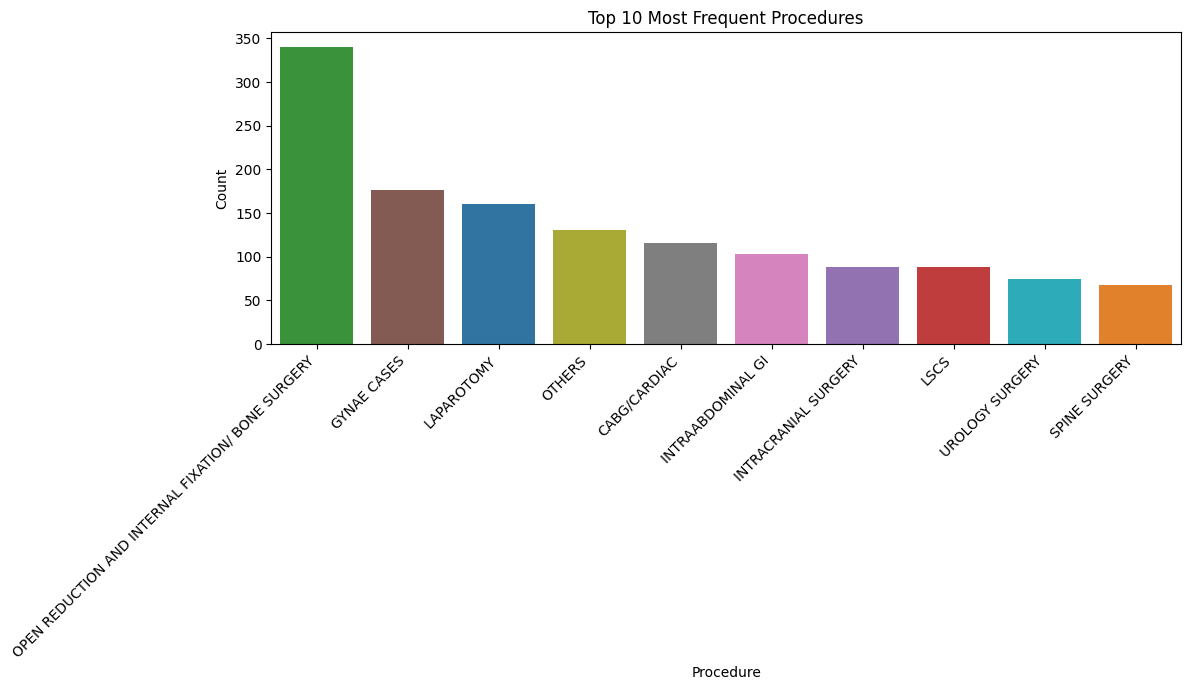

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the top 10 most frequent procedures
top_10_procedures = df1['PROCEDURE SEGREGATED'].value_counts().head(10).index.tolist()

# Filter the DataFrame to include only these top 10 procedures
df_top_procedures = df1[df1['PROCEDURE SEGREGATED'].isin(top_10_procedures)]

plt.figure(figsize=(12, 7))
sns.countplot(data=df_top_procedures, x='PROCEDURE SEGREGATED', hue='PROCEDURE SEGREGATED', palette='tab10', legend=False, order=top_10_procedures)
plt.title('Top 10 Most Frequent Procedures')
plt.xlabel('Procedure')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
print(f"Number of unique diagnosis: {df1['DIAGNOSIS'].nunique()}")
display(df1['DIAGNOSIS'].value_counts().head(10))

Number of unique diagnosis: 1127


,count
DIAGNOSIS,
ANC,22
IHD WITH TVD,15
CA BREAST,14
PERFORATION PERITONITIS,14
B/L KNEE OSTEOARTHRITIS,13
CHOLELITHIASIS,12
RHD WITH MS,12
INTESTINAL OBSTRUCTION,11
ACUTE INTESTINAL OBSTRUCTION,10


In [ ]:
print(f"Number of unique DEPARTMENT: {df1['DEPARTMENT'].nunique()}")
display(df1['DEPARTMENT'].value_counts().head(10))

Number of unique DEPARTMENT: 39


,count
DEPARTMENT,
ORTHO,518
OBG,307
GEN SURG,247
NEURO SURG,130
SURG GASTRO,85
CTVS,77
UROLOGY,74
SURG ONCO,47
PEDS SURG,44


In [ ]:
df.head()

,SL. NO,DATE,BBR NO,HOSP NO,AGE,GENDER,DEPARTMENT,UNIT,DIAGNOSIS,PROCEDURE SEGREGATED,BLOOD UNITS REQUESTED,BLOOD UNITS CROSSMATCHED,BLOOD UNITS ISSUES,PRE HB
0,1,23/1/24,1041.0,1438616.0,15,F,PEDS SURG,0.0,PSEUDOCYST PANCREAS,LAPAROTOMY,1,1.0,0,8.2
1,2,22/1/24,990.0,687102.0,11,F,PEDS SURG,0.0,PERSISTENT CLOACA,LAPAROTOMY,2,1.0,1,12.9
2,3,23/1/24,1059.0,854359.0,63,F,SURG ONCO,0.0,CA RIGHT BREAST,MASTECTOMY,2,0.0,0,12.5
3,4,23.1.24,1058.0,1431486.0,74,F,SURG ONCO,0.0,CA RIGHT BREAST,MASTECTOMY,2,0.0,0,10.7
4,5,24/1/24,1047.0,29681.0,42,M,NEURO SURG,0.0,L4 L5 DISC PROLAPSE,SPINE SURGERY,1,0.0,0,14.3


In [ ]:
df=df.iloc[0:1500]

In [ ]:
df.shape

(1500, 14)

In [ ]:
test_data=df.iloc[1500:]

In [ ]:
x.shape

(1500, 5)

In [ ]:
target.shape

(1500,)

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1507
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   AGE                   1500 non-null   object
 1   GENDER                1500 non-null   object
 2   DEPARTMENT            1500 non-null   object
 3   PROCEDURE SEGREGATED  1500 non-null   object
 4   PRE HB                1500 non-null   object
dtypes: object(5)
memory usage: 70.3+ KB


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()

In [ ]:
x =x.apply(label_encoder.fit_transform)

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1507
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   AGE                   1500 non-null   int64
 1   GENDER                1500 non-null   int64
 2   DEPARTMENT            1500 non-null   int64
 3   PROCEDURE SEGREGATED  1500 non-null   int64
 4   PRE HB                1500 non-null   int64
dtypes: int64(5)
memory usage: 70.3 KB


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, target, test_size=0.20, random_state=42)

In [ ]:
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (1200, 5)
x_test shape: (300, 5)
y_train shape: (1200,)
y_test shape: (300,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [ ]:
dtree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train the model
dtree.fit(x_train, y_train)

# 4. Make Predictions
y_pred = dtree.predict(x_test)

In [ ]:
accuracy_dtree = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_dtree}")
print(f"Predictions for test set: {y_pred}")



Accuracy: 0.78
Predictions for test set: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='auto', random_state=42)

# 4. Train the model (fit the data)
svm_model.fit(x_train, y_train)

# 5. Make predictions on the test set
y_pred = svm_model.predict(x_test)

In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred)
print(f"Accuracy of the SVM model on the test data: {accuracy_svm:.2f}")


Accuracy of the SVM model on the test data: 0.76


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_rf = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy_rf * 100:.2f}%')



Accuracy: 76.33%


In [ ]:
print('Random Forest',accuracy_rf)
print('Decision Tree',accuracy_dtree)
print('SVM',accuracy_svm)

Random Forest 0.7633333333333333
Decision Tree 0.78
SVM 0.7633333333333333
